In [1]:
import os
import torch
from open_clip import create_model_from_pretrained, get_tokenizer
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import torch.nn.functional as F

In [2]:
# ------------------------------
# CONFIGURATION
# ------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Real directories (200 images each)
REAL_MILD_DIR   = "/data/liangz2/image_quality/real_images/mild"    # 200 mild pneumonia CXRs
REAL_SEVERE_DIR = "/data/liangz2/image_quality/real_images/severe"  # 200 severe pneumonia CXRs

# Synthetic directories for the 12 types:
SYNTH_DIRS = {
    "SD21_i2i_mild":   "/data/liangz2/image_quality/fake_images/sd21/sd21_i2i_mild",      # #1
    "SD21_i2i_severe": "/data/liangz2/image_quality/fake_images/sd21/sd21_i2i_severe",    # #2
    "SD21_t2i_mild":   "/data/liangz2/image_quality/fake_images/sd21/sd21_t2i_mild",      # #3
    "SD21_t2i_severe": "/data/liangz2/image_quality/fake_images/sd21/sd21_t2i_severe",    # #4
    "SD35_i2i_mild":   "/data/liangz2/image_quality/fake_images/sd35/sd35_i2i_mild",      # #5
    "SD35_i2i_severe": "/data/liangz2/image_quality/fake_images/sd35/sd35_i2i_severe",    # #6
    "SD35_t2i_mild":   "/data/liangz2/image_quality/fake_images/sd35/sd35_t2i_mild",      # #7
    "SD35_t2i_severe": "/data/liangz2/image_quality/fake_images/sd35/sd35_t2i_severe",    # #8
    "StyleGAN2_mild":  "/data/liangz2/image_quality/fake_images/stylegan2/mild",     # #9
    "StyleGAN2_severe":"/data/liangz2/image_quality/fake_images/stylegan2/severe",   # #10
    "StyleGAN3_mild":  "/data/liangz2/image_quality/fake_images/stylegan3/mild",     # #11
    "StyleGAN3_severe":"/data/liangz2/image_quality/fake_images/stylegan3/severe",   # #12
}

# 3) Fine‐tuned model path
MODEL_NAME = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
SAVE_PATH  = "./biomedclip_model/biomedclip_visual_finetuned.pth"

In [3]:
# ----------------------------------------
# 1. Load fine‐tuned BiomedCLIP vision encoder + processor
# ----------------------------------------
vision_model, processor = create_model_from_pretrained(
    MODEL_NAME,
    return_transform=True
)
# Load fine‐tuned visual weights
vision_model.visual.load_state_dict(torch.load(SAVE_PATH, map_location="cpu"))
vision_model = vision_model.to(DEVICE).eval()
print(f"Loaded fine‐tuned weights from {SAVE_PATH} onto {DEVICE}")

# ----------------------------------------
# 2. Helper: batch‐compute embeddings for all images in a folder
# ----------------------------------------
def load_embeddings(folder: str, batch_size: int = 32):
    """
    Compute BiomedCLIP embeddings for every image in `folder` (sorted by filename).
    Returns:
      - embs: NumPy array of shape (N, D)
      - paths: list of length N with the corresponding full file paths
    """
    filenames = sorted([
        fn for fn in os.listdir(folder)
        if fn.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tiff"))
    ])
    paths = [os.path.join(folder, fn) for fn in filenames]
    all_embs = []

    for i in tqdm(range(0, len(paths), batch_size), desc=f"Embedding {os.path.basename(folder)}"):
        batch_paths = paths[i : i + batch_size]
        imgs = [Image.open(p).convert("RGB") for p in batch_paths]
        # processor resizes to 224×224 and normalizes
        pix = torch.stack([processor(img) for img in imgs], dim=0).to(DEVICE)  # (B, 3, 224, 224)

        with torch.no_grad():
            feats = vision_model.encode_image(pix)    # (B, D)
            feats = F.normalize(feats, dim=-1)        # unit‐normalize
        all_embs.append(feats.cpu().numpy())

    all_embs = np.concatenate(all_embs, axis=0)      # shape: (N, D)
    return all_embs, paths

Loaded fine‐tuned weights from ./biomedclip_model/biomedclip_visual_finetuned.pth onto cuda


In [4]:
# ----------------------------------------
# 3. Compute embeddings for real mild and real severe images
# ----------------------------------------
real_mild_embs, real_mild_paths     = load_embeddings(REAL_MILD_DIR, batch_size=32)
real_severe_embs, real_severe_paths = load_embeddings(REAL_SEVERE_DIR, batch_size=32)

# Convert to torch.Tensor on DEVICE if needed later
real_mild_tensor   = torch.from_numpy(real_mild_embs).to(DEVICE)    # (200, D)
real_severe_tensor = torch.from_numpy(real_severe_embs).to(DEVICE)  # (200, D)

# ----------------------------------------
# 4. Compute embeddings for all 12 synthetic sets
#    Store in a dictionary: name → { "embs", "paths", "tensor" }
# ----------------------------------------
synth_emb_dict = {}
for name, folder in SYNTH_DIRS.items():
    embs, paths = load_embeddings(folder, batch_size=32)
    synth_emb_dict[name] = {
        "embs":   embs,
        "paths":  paths,
        "tensor": torch.from_numpy(embs).to(DEVICE)  # (1000, D)
    }

# At this point:
#   - real_mild_embs  is a NumPy array (200, D)
#   - real_severe_embs is a NumPy array (200, D)
#   - synth_emb_dict[name]["embs"] is a NumPy array (1000, D)
#   - synth_emb_dict[name]["tensor"] is a torch.Tensor on DEVICE

# You can save these for later use, e.g.:
# np.save("real_mild_embs.npy", real_mild_embs)
# np.save("real_severe_embs.npy", real_severe_embs)
# For each generator:
#   np.save(f"{name}_embs.npy", synth_emb_dict[name]["embs"])

Embedding severe: 100%|██████████| 32/32 [00:12<00:00,  2.65it/s]


In [5]:
# ----------------------------------------
# 5. Compute real‐class centroids
# ----------------------------------------

with torch.no_grad():
    # Normalize real embeddings first
    real_mild_norm   = F.normalize(real_mild_tensor,   dim=-1)  # (200, D)
    real_severe_norm = F.normalize(real_severe_tensor, dim=-1)  # (200, D)

    # Compute & re‐normalize the centroid (mean of unit vectors → unit vector)
    centroid_mild   = F.normalize(real_mild_norm.mean(dim=0, keepdim=True),   dim=-1)  # (1, D)
    centroid_severe = F.normalize(real_severe_norm.mean(dim=0, keepdim=True), dim=-1)  # (1, D)

# ----------------------------------------
# 6. For each synthetic set, compute constraint metrics (cosine similarity to the centroid)
# ----------------------------------------

records = []
for name, data in synth_emb_dict.items():
    # Pick the appropriate centroid based on "_mild" vs "_severe"
    if name.endswith("_mild"):
        target_centroid = centroid_mild     # (1, D)
        severity_label  = "mild"
    else:
        target_centroid = centroid_severe   # (1, D)
        severity_label  = "severe"

    synth_tensor = data["tensor"]          # (N_synth, D)
    with torch.no_grad():
        # Normalize synthetic embeddings
        synth_norm = F.normalize(synth_tensor, dim=-1)  # (N_synth, D)

        # Cosine similarity to centroid: (N_synth, D) @ (D, 1) → (N_synth,)
        sims = (synth_norm @ target_centroid.T).squeeze(1)

        # Compute mean and std of these similarities
        mean_sim = sims.mean().item()
        std_sim  = sims.std().item()

    records.append({
        "Generator":    name,
        "Severity":     severity_label,
        "Num_Synth":    synth_tensor.size(0),
        "Mean_CosSim":  mean_sim,
        "Std_CosSim":   std_sim,
    })


In [6]:
# ----------------------------------------
# 7. Build a DataFrame and save
# ----------------------------------------

constraint_df = pd.DataFrame.from_records(records)
constraint_csv = "/data/liangz2/biomedclip_model/constraint_scores_biomedclip.csv"
os.makedirs(os.path.dirname(constraint_csv), exist_ok=True)
constraint_df.to_csv(constraint_csv, index=False)
print(f"Saved constraint scores to {constraint_csv}")
print(constraint_df)

Saved constraint scores to /data/liangz2/biomedclip_model/constraint_scores_biomedclip.csv
           Generator Severity  Num_Synth  Mean_CosSim  Std_CosSim
0      SD21_i2i_mild     mild       1000     0.847591    0.060607
1    SD21_i2i_severe   severe       1000     0.386657    0.165307
2      SD21_t2i_mild     mild       1000     0.875960    0.039198
3    SD21_t2i_severe   severe       1000     0.423921    0.111583
4      SD35_i2i_mild     mild       1000     0.776149    0.079478
5    SD35_i2i_severe   severe       1000     0.117576    0.099880
6      SD35_t2i_mild     mild       1000     0.787054    0.070258
7    SD35_t2i_severe   severe       1000     0.166748    0.097387
8     StyleGAN2_mild     mild       1000     0.593365    0.284037
9   StyleGAN2_severe   severe       1000     0.535849    0.305295
10    StyleGAN3_mild     mild       1000     0.642586    0.266439
11  StyleGAN3_severe   severe       1000     0.473942    0.302949


/tmp/ipykernel_2277817/3756365536.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_2277817/3756365536.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2277817/3756365536.py:51: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_2277817/3756365536.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Saved constraint plot to /data/liangz2/biomedclip_model/constraint_barplot.png


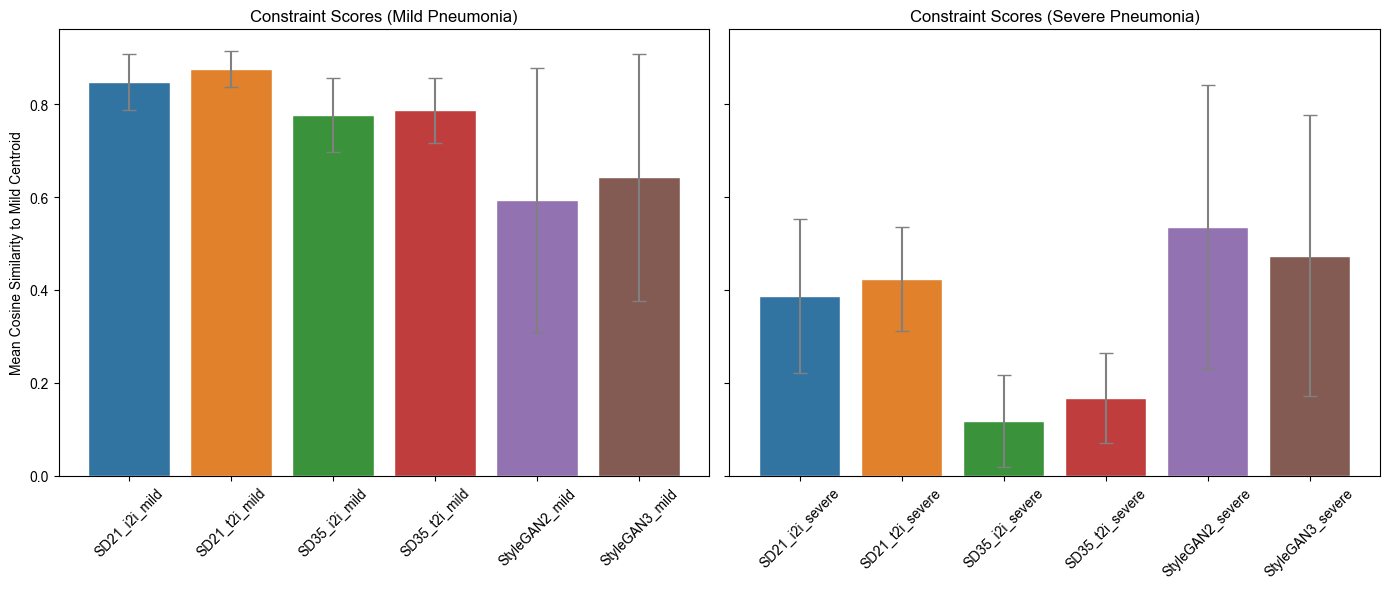

In [7]:
# ----------------------------------------
# 8. Plot the results
# ----------------------------------------
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the constraint scores CSV
constraint_csv = "/data/liangz2/biomedclip_model/constraint_scores_biomedclip.csv"
constraint_df = pd.read_csv(constraint_csv)

# 2. Split the DataFrame into mild and severe subsets
df_mild   = constraint_df[constraint_df["Severity"] == "mild"].reset_index(drop=True)
df_severe = constraint_df[constraint_df["Severity"] == "severe"].reset_index(drop=True)

# 3. Create a figure with two subplots (shared y-axis)
fig, (ax_mild, ax_severe) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
sns.set_style("whitegrid")

# 4. Plot mild generators (bars only, no internal CI)
sns.barplot(
    data=df_mild,
    x="Generator",
    y="Mean_CosSim",
    palette="tab10",
    ax=ax_mild,
    ci=None  # disable Seaborn’s internal error computation
)
ax_mild.set_title("Constraint Scores (Mild Pneumonia)")
ax_mild.set_xlabel("")  # remove the "Generator" label
ax_mild.set_ylabel("Mean Cosine Similarity to Mild Centroid")
ax_mild.tick_params(axis='x', rotation=45, labelsize=10)

# 4a. Manually add error bars for mild
for i, row in df_mild.iterrows():
    x_center = i  # Seaborn plots bars in the same order as df_mild indices
    y = row["Mean_CosSim"]
    err = row["Std_CosSim"]
    ax_mild.errorbar(
        x=x_center,
        y=y,
        yerr=err,
        fmt="none",           # no marker
        ecolor="gray",
        elinewidth=1.5,
        capsize=5
    )

# 5. Plot severe generators (bars only)
sns.barplot(
    data=df_severe,
    x="Generator",
    y="Mean_CosSim",
    palette="tab10",
    ax=ax_severe,
    ci=None
)
ax_severe.set_title("Constraint Scores (Severe Pneumonia)")
ax_severe.set_xlabel("")  # remove the "Generator" label
ax_severe.set_ylabel("")  # share y-label with left plot
ax_severe.tick_params(axis='x', rotation=45, labelsize=10)

# 5a. Manually add error bars for severe
for i, row in df_severe.iterrows():
    x_center = i
    y = row["Mean_CosSim"]
    err = row["Std_CosSim"]
    ax_severe.errorbar(
        x=x_center,
        y=y,
        yerr=err,
        fmt="none",
        ecolor="gray",
        elinewidth=1.5,
        capsize=5
    )

# 6. Finalize layout and save
plt.tight_layout()
plot_dir = "/data/liangz2/biomedclip_model"
os.makedirs(plot_dir, exist_ok=True)
plot_path = os.path.join(plot_dir, "constraint_barplot.png")
plt.savefig(plot_path, dpi=300)

print(f"Saved constraint plot to {plot_path}")

